# PEGASUS Transformer

## Data Preprocessing

### Train Data

In [4]:
 !git clone https://github.com/ryanzhumich/AESLC.git

Cloning into 'AESLC'...
remote: Enumerating objects: 17469, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 17469 (delta 1), reused 0 (delta 0), pack-reused 17461 (from 1)
Receiving objects: 100% (17469/17469), 7.36 MiB | 18.79 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [5]:
import os
import pandas as pd
import string
import numpy as np

In [6]:
def clean_text(text):
  text = text.lower() # lower case
  text = text.replace('\n',' ') # removing \n
  remove_punc = str.maketrans('', '', string.punctuation)
  text = text.translate(remove_punc) # removing special characters
  text = ' '.join(text.split()) # removing unneccessary space
  return text

In [7]:
emails = []
subjects = []

file_dir = 'AESLC/enron_subject_line/train'
for file_name in os.listdir(file_dir):
  file_path = os.path.join(file_dir, file_name)
  with open(file_path, "r") as f:
    text = f.read()
    email_contents,subject = text.split('@subject\n')     
    emails.append(email_contents)
    subjects.append(subject)

In [8]:
mail_sub_data = pd.DataFrame({'email':emails,'subject':subjects})
mail_sub_data['clean_subject'] = mail_sub_data['subject'].apply(clean_text)
mail_sub_data['clean_email'] = mail_sub_data['email'].apply(clean_text)
mail_sub_data["input_text"] = "summarize: " + mail_sub_data["clean_email"]
mail_sub_data

,email,subject,clean_subject,clean_email,input_text
0,Take a look at my worksheet and let me know wh...,CGAS Storage,cgas storage,take a look at my worksheet and let me know wh...,summarize: take a look at my worksheet and let...
1,Chris: We need to discuss the alternative to ...,Southern California Water Company,southern california water company,chris we need to discuss the alternative to sp...,summarize: chris we need to discuss the altern...
2,"Nancy, Please find attached the form for the ...",New Book Request - NG-PR-OPTLT,new book request ngproptlt,nancy please find attached the form for the ne...,summarize: nancy please find attached the form...
3,"Holden,=20 =20 My name is Stuart Wright and I ...",Checking in...,checking in,holden20 20 my name is stuart wright and i am ...,summarize: holden20 20 my name is stuart wrigh...
4,"=09 =09 Dear Randy, I'm Washington Bureau ...",Williams Energy News Live -- today's video new...,williams energy news live todays video newscast,09 09 dear randy im washington bureau chief pe...,summarize: 09 09 dear randy im washington bure...
...,...,...,...,...,...
14431,"Everyone, We are in the process of creating n...",Market Data Contracts,market data contracts,everyone we are in the process of creating new...,summarize: everyone we are in the process of c...
14432,Attached are redlined versions of an amended a...,LLC and Admin. Agreement Revisions,llc and admin agreement revisions,attached are redlined versions of an amended a...,summarize: attached are redlined versions of a...
14433,"Dear Greg, As we discussed, I am attaching ou...","Draft ISDA-Ontario Power Generation, Inc.",draft isdaontario power generation inc,dear greg as we discussed i am attaching our p...,summarize: dear greg as we discussed i am atta...
14434,Geetings Kevin: Wanted to touch base to make ...,CNRL release,cnrl release,geetings kevin wanted to touch base to make su...,summarize: geetings kevin wanted to touch base...


### Test Data

In [9]:
emails = []
subjects = []
email_id = []
file_dir = 'AESLC/enron_subject_line/test'
for file_name in os.listdir(file_dir):
  file_path = os.path.join(file_dir, file_name)
  with open(file_path, "r") as f:
    text = f.read()
    email_contents,text = text.split('@subject\n')
    subject,text = text.split('\n\n@ann0\n')    
    emails.append(email_contents)
    subjects.append(subject)

In [10]:
test_data = pd.DataFrame({'email':emails,'subject':subjects})
test_data['clean_email'] = test_data['email'].apply(clean_text)
test_data

,email,subject,clean_email
0,I don't think I gave you George Briden's numbe...,caithness,i dont think i gave you george bridens number ...
1,When this email reaches you I pray that you ar...,Good Morning :),when this email reaches you i pray that you ar...
2,"June 16, 2000 Energen Resources Corporation ...",Master Gas Agreement,june 16 2000 energen resources corporation in ...
3,"Bruce, Please launch the attached file to see...",C/P Name Changes on old Deals,bruce please launch the attached file to see a...
4,Michelle: Could you please send me the latest...,Consulting Agreement,michelle could you please send me the latest f...
...,...,...,...
1901,Attached please find the short form collateral...,Short Form WSPP Collateral Annex,attached please find the short form collateral...
1902,"Andy - Per our conversation, can you please p...",Michcon Market,andy per our conversation can you please provi...
1903,"As I mentioned in my voice mail, please check ...",Tony Pryor,as i mentioned in my voice mail please check u...
1904,KUDLOW'S TAKE by Lawrence Kudlow DECLARING W...,KUDLOW'S TAKE -- National Review Online Financ...,kudlows take by lawrence kudlow declaring war ...


## PEGASUS Transformer

In [12]:
import torch
from datasets import Dataset
from transformers import  Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, PegasusForConditionalGeneration
from transformers import EarlyStoppingCallback

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = PegasusForConditionalGeneration .from_pretrained("google/pegasus-xsum")
tokenizer = AutoTokenizer.from_pretrained("google/pegasus-xsum")

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

In [14]:
def generate_subject(text):
    input_ids = tokenizer.encode(
        f"summarize: {text}",
        return_tensors="pt",
        max_length=100,
        truncation=True,
        padding="max_length"
    ).to(device)
    output_ids = model.generate(
        input_ids,
        max_length=15,
        num_beams=5,
        early_stopping=True
    )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [15]:
pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=2522e5195da9608943470940ccba9e4f0830eea49a15a37da23b1173c649b03c
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score
Note: you may need to restart the kernel to use updated packages.


In [16]:
from rouge_score import rouge_scorer
from tqdm import tqdm

subject = []

scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
for text, reference in tqdm(zip(test_data['clean_email'],test_data['subject'])):
  predicted = generate_subject(text)
  subject.append(predicted)
  score = scorer.score(reference.lower(), predicted.lower())
  scores['rouge1'].append(score['rouge1'].fmeasure)
  scores['rouge2'].append(score['rouge2'].fmeasure)
  scores['rougeL'].append(score['rougeL'].fmeasure)

test_data['predicted_subject'] = subject
avg_rouge1 = np.mean(scores['rouge1'])
avg_rouge2 = np.mean(scores['rouge2'])
avg_rougeL = np.mean(scores['rougeL'])

print(f"\nROUGE-1 F1: {avg_rouge1:.4f}")
print(f"ROUGE-2 F1: {avg_rouge2:.4f}")
print(f"ROUGE-L F1: {avg_rougeL:.4f}")

1906it [08:42,  3.65it/s]


ROUGE-1 F1: 0.0660
ROUGE-2 F1: 0.0170
ROUGE-L F1: 0.0612


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


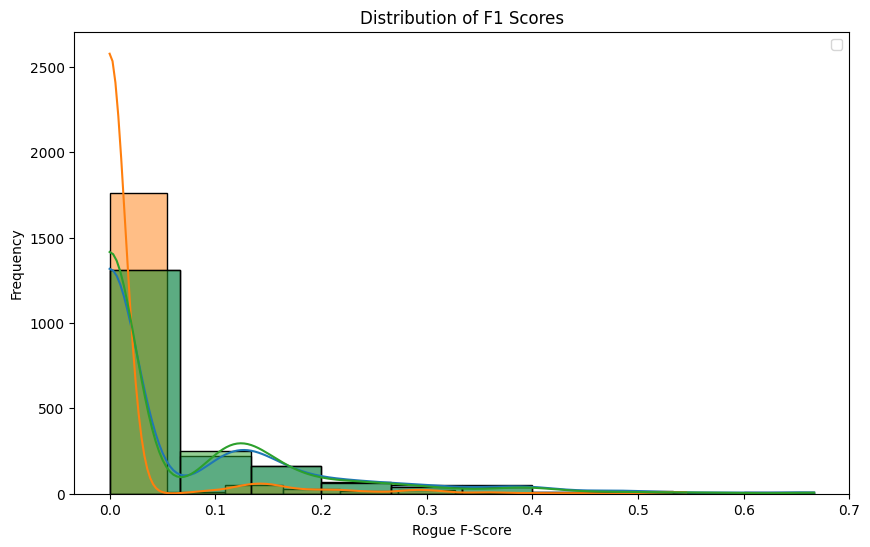

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(scores['rouge1'], bins=10, kde=True)
sns.histplot(scores['rouge2'], bins=10, kde=True)
sns.histplot(scores['rougeL'], bins=10, kde=True)
plt.xlabel('Rogue F-Score')
plt.ylabel('Frequency')
plt.title('Distribution of F1 Scores')
plt.legend()
plt.show()

In [19]:
test_data['predicted_subject'] = subject
test_data

,email,subject,clean_email,predicted_subject
0,Just FYI - I believe you entered these deals o...,Los Angeles Department of Water and Power IS N...,just fyi i believe you entered these deals on ...,Jamie Coleman:
1,It's clear the Ebay made the error in this ma...,item#1065594740,its clear the ebay made the error in this matt...,"Hi all, i have just received an email from eba..."
2,I am pleased to announce the following organiz...,EGM Operations & Accounting Organizational Cha...,i am pleased to announce the following organiz...,Here is the full text of the statement issued ...
3,Harry: Got the bid documents for ConEd's offe...,ConEd - Lakewood Peaker,harry got the bid documents for coneds offerin...,Manchester City have put their proposed new st...
4,"Once again, Enron employees showed their gener...",March of Dimes Raffle Update,once again enron employees showed their genero...,All proceeds from this year's march of dimes r...
...,...,...,...,...
1901,"Mark--one of my colleagues, Bob Frank, is goin...",Colorado PUC NOv 1,markone of my colleagues bob frank is going to...,The chairman of the Energy and Climate Change ...
1902,"Guys, I will forward the info as it becomes av...",Wind Info/Cost to Build,guys i will forward the info as it becomes ava...,What do you think is the best way to go about ...
1903,FYI.\nI spoke with Lisa Mellencamp about Donal...,Employment Opportunities/Job No. 103079/Sr. Le...,fyi i spoke with lisa mellencamp about donald ...,"Donald Trump's former personal lawyer, Michael..."
1904,Fifth grade assignment The teacher gave her f...,Every day needs a little dose of levity...,fifth grade assignment the teacher gave her fi...,In our series of letters from African-American...


### Training

In [17]:
dataset = Dataset.from_pandas(mail_sub_data[["input_text", "subject"]])
dataset = dataset.train_test_split(test_size=0.1)

max_input_length = 500
max_subject_length = 14

def preprocess(df):
  inputs = tokenizer(df["input_text"], padding="max_length", truncation=True, max_length=max_input_length)
  targets = tokenizer(df["subject"], padding="max_length", truncation=True, max_length=max_subject_length)
  inputs["labels"] = targets["input_ids"]
  return inputs

tokenized_dataset = dataset.map(preprocess, batched=True)

Map:   0%|          | 0/12992 [00:00<?, ? examples/s]

Map:   0%|          | 0/1444 [00:00<?, ? examples/s]

In [19]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [20]:

training_args = TrainingArguments(
    output_dir="./bart_summarizer",    
    learning_rate=5e-5,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipykernel_31/3682527072.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,2.964700,1.697293
2,1.667600,1.639874


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3339: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 64, 'num_beams': 8, 'length_penalty': 0.6}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=3248, training_loss=2.316139709773322, metrics={'train_runtime': 5681.5978, 'train_samples_per_second': 4.573, 'train_steps_per_second': 0.572, 'total_flos': 3.6660079755264e+16, 'train_loss': 2.316139709773322, 'epoch': 2.0})

In [27]:
import shutil

model.save_pretrained("finetuned_pegasus_model")
tokenizer.save_pretrained("finetuned_pegasus_model")
shutil.make_archive("finetuned_pegasus_model", 'zip', "finetuned_pegasus_model")

'/kaggle/working/finetuned_pegasus_model.zip'

In [21]:
pip install rouge_score

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [22]:
from rouge_score import rouge_scorer
from tqdm import tqdm

subject = []

scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
for text, reference in tqdm(zip(test_data['clean_email'],test_data['subject'])):
  predicted = generate_subject(text)
  subject.append(predicted)
  score = scorer.score(reference.lower(), predicted.lower())
  scores['rouge1'].append(score['rouge1'].fmeasure)
  scores['rouge2'].append(score['rouge2'].fmeasure)
  scores['rougeL'].append(score['rougeL'].fmeasure)

test_data['predicted_subject'] = subject
avg_rouge1 = np.mean(scores['rouge1'])
avg_rouge2 = np.mean(scores['rouge2'])
avg_rougeL = np.mean(scores['rougeL'])

print(f"\nROUGE-1 F1: {avg_rouge1:.4f}")
print(f"ROUGE-2 F1: {avg_rouge2:.4f}")
print(f"ROUGE-L F1: {avg_rougeL:.4f}")

1906it [03:58,  7.98it/s]


ROUGE-1 F1: 0.2938
ROUGE-2 F1: 0.1433
ROUGE-L F1: 0.2872


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


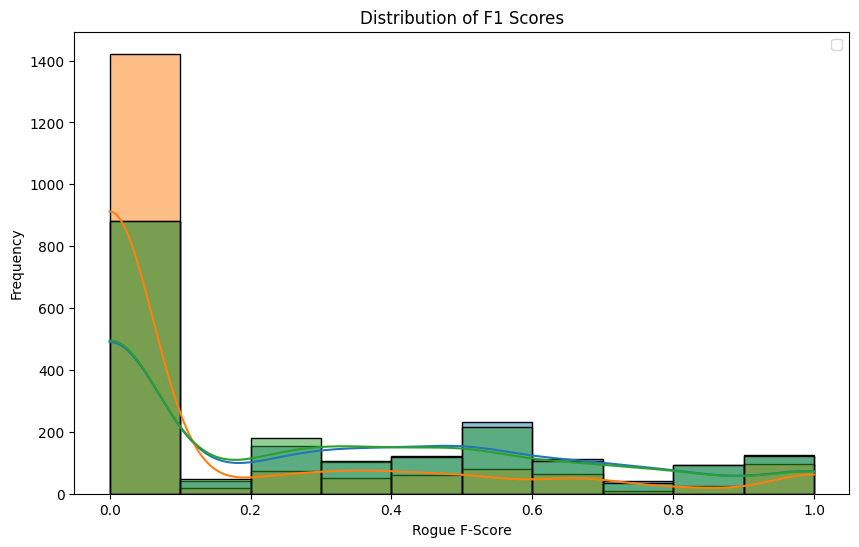

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(scores['rouge1'], bins=10, kde=True)
sns.histplot(scores['rouge2'], bins=10, kde=True)
sns.histplot(scores['rougeL'], bins=10, kde=True)
plt.xlabel('Rogue F-Score')
plt.ylabel('Frequency')
plt.title('Distribution of F1 Scores')
plt.legend()
plt.show()

In [26]:
test_data['predicted_subject'] = subject
test_data['rouge1'] = scores['rouge1']
test_data['rouge2'] = scores['rouge2']
test_data['rougeL'] = scores['rougeL']
test_data.to_csv('test_data.csv')

test_data

,email,subject,clean_email,predicted_subject,rouge1,rouge2,rougeL
0,I don't think I gave you George Briden's numbe...,caithness,i dont think i gave you george bridens number ...,Contact Info,0.000000,0.0,0.000000
1,When this email reaches you I pray that you ar...,Good Morning :),when this email reaches you i pray that you ar...,Hello,0.000000,0.0,0.000000
2,"June 16, 2000 Energen Resources Corporation ...",Master Gas Agreement,june 16 2000 energen resources corporation in ...,Master Firm Purchase Agreement,0.571429,0.0,0.571429
3,"Bruce, Please launch the attached file to see...",C/P Name Changes on old Deals,bruce please launch the attached file to see a...,Girotondo,0.000000,0.0,0.000000
4,Michelle: Could you please send me the latest...,Consulting Agreement,michelle could you please send me the latest f...,ENA,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...
1901,Attached please find the short form collateral...,Short Form WSPP Collateral Annex,attached please find the short form collateral...,collateral support annex,0.500000,0.0,0.500000
1902,"Andy - Per our conversation, can you please p...",Michcon Market,andy per our conversation can you please provi...,Index Quote,0.000000,0.0,0.000000
1903,"As I mentioned in my voice mail, please check ...",Tony Pryor,as i mentioned in my voice mail please check u...,signing bonus,0.000000,0.0,0.000000
1904,KUDLOW'S TAKE by Lawrence Kudlow DECLARING W...,KUDLOW'S TAKE -- National Review Online Financ...,kudlows take by lawrence kudlow declaring war ...,Economic Call to Arms,0.000000,0.0,0.000000
